<a href="https://colab.research.google.com/github/tubak8665-lgtm/Credit-Card-risk-analysis-/blob/main/Credit_Card_Transaction_Risk_and_Statistical_Analysis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Credit Card Transaction Risk and Statistical Analysis System

# Explanation:
This code creates a synthetic credit-card transaction dataset containing transaction type, location type,and transaction status.


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "Transaction_ID": np.arange(1, n + 1),
    "Transaction_Amount": np.round(
        np.random.lognormal(7, 1, n), 2
    ),
    "Transaction_Hour": np.random.randint(0, 24, n),
    "Transaction_Day": np.random.randint(1, 31, n),
    "Transaction_Type": np.random.choice(
        ["Online", "POS", "ATM"],
        n
    ),
    "Location_Type": np.random.choice(
        ["Local", "Domestic", "International"],
        n
    ),
    "Transaction_Status": np.random.choice(
        ["Normal", "Suspicious"],
        n,
        p=[0.90, 0.10]
    )
}

df = pd.DataFrame(data)

df.head()

,Transaction_ID,Transaction_Amount,Transaction_Hour,Transaction_Day,Transaction_Type,Location_Type,Transaction_Status
0,1,1802.11,22,18,ATM,Domestic,Normal
1,2,955.02,11,20,ATM,International,Normal
2,3,2095.80,16,17,Online,Local,Normal
3,4,5029.27,7,27,Online,International,Normal
4,5,867.70,10,28,Online,Local,Normal


# Explanation:
This code checks the size, column names, data types, and first few records of the dataset.


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 10 Records:")
display(df.head(10))

Rows: 1000
Columns: 7

Columns:
['Transaction_ID', 'Transaction_Amount', 'Transaction_Hour', 'Transaction_Day', 'Transaction_Type', 'Location_Type', 'Transaction_Status']

Data Types:
Transaction_ID          int64
Transaction_Amount    float64
Transaction_Hour        int64
Transaction_Day         int64
Transaction_Type       object
Location_Type          object
Transaction_Status     object
dtype: object

First 10 Records:


,Transaction_ID,Transaction_Amount,Transaction_Hour,Transaction_Day,Transaction_Type,Location_Type,Transaction_Status
0,1,1802.11,22,18,ATM,Domestic,Normal
1,2,955.02,11,20,ATM,International,Normal
2,3,2095.80,16,17,Online,Local,Normal
3,4,5029.27,7,27,Online,International,Normal
4,5,867.70,10,28,Online,Local,Normal
5,6,867.71,2,27,POS,Local,Normal
6,7,5319.92,5,15,POS,Domestic,Normal
7,8,2362.40,8,11,POS,Local,Normal
8,9,685.76,5,25,Online,Local,Normal
9,10,1886.65,8,28,ATM,Domestic,Normal


# This code checks every column for missing values and calculates the total number of missing entries.

In [ ]:
missing = df.isnull().sum()

print(missing)

print("\nTotal missing values:", missing.sum())

Transaction_ID        0
Transaction_Amount    0
Transaction_Hour      0
Transaction_Day       0
Transaction_Type      0
Location_Type         0
Transaction_Status    0
dtype: int64

Total missing values: 0


Observation:

The dataset does not contain any missing values, so no missing-value treatment is required at this stage.

Explanation:
This code identifies the number of completely duplicated record in the dataset.



In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate records:", duplicates)

Duplicate records: 0


# Explanation:
This analysis summarizes transaction amount and show
how transactions are distributed across
transaction types, locations, and statuses.

In [ ]:
amount_stats = df["Transaction_Amount"].describe()

print(amount_stats)

print("\nTransaction Type:")
print(df["Transaction_Type"].value_counts())

print("\nLocation Type:")
print(df["Location_Type"].value_counts())

print("\nTransaction Status:")
print(df["Transaction_Status"].value_counts())

count     1000.000000
mean      1844.903350
std       2682.530918
min         42.890000
25%        573.875000
50%       1124.730000
75%       2096.335000
max      51675.110000
Name: Transaction_Amount, dtype: float64

Transaction Type:
Transaction_Type
Online    346
ATM       335
POS       319
Name: count, dtype: int64

Location Type:
Location_Type
International    343
Local            331
Domestic         326
Name: count, dtype: int64

Transaction Status:
Transaction_Status
Normal        910
Suspicious     90
Name: count, dtype: int64


## Transaction Amount Distribution

# Explantion:
This code calculates basic measures of transaction amounts and visualize their distribution using a histogram.

In [ ]:
import matplotlib.pyplot as plt

Mean: 1844.90335
Median: 1124.73
Minimum: 42.89
Maximum: 51675.11


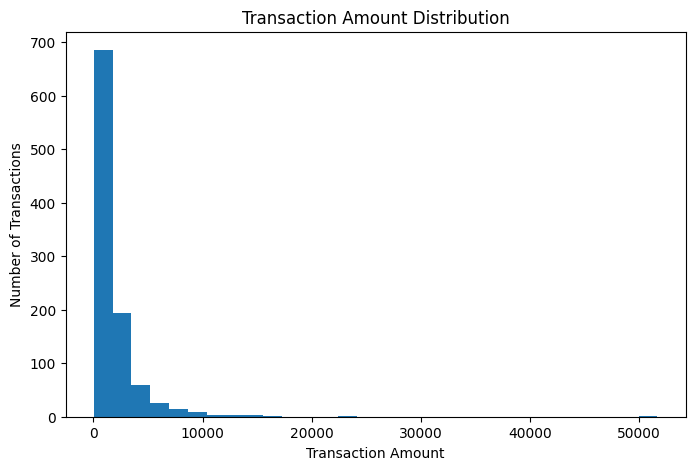

In [ ]:
amount = df["Transaction_Amount"]

print("Mean:", amount.mean())
print("Median:", amount.median())
print("Minimum:", amount.min())
print("Maximum:", amount.max())

plt.figure(figsize=(8, 5))
plt.hist(amount, bins=30)
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.show()

## Transation Amount Variability Analysis

# Explanation:
This code measures the variability of transation amounts. Standard devivation show how widely the transaction values are spread around the mean.

In [ ]:
mean_amount = df["Transaction_Amount"].mean()
variance_amount = df["Transaction_Amount"].var()
std_amount = df["Transaction_Amount"].std()

print("Mean:", round(mean_amount, 2))
print("Variance:", round(variance_amount, 2))
print("Standard Deviation:", round(std_amount, 2))

Mean: 1844.9
Variance: 7195972.12
Standard Deviation: 2682.53


## Transaction Amount Range Analysis

# Explanation:
The transaction were divide into Low, Medium and High amount ranges. The averge transation amount increases across the range, allowing furture comparison of transation behavior and risk patterns.

In [ ]:
q1 = df["Transaction_Amount"].quantile(0.33)
q2 = df["Transaction_Amount"].quantile(0.66)

df["Amount_Range"] = pd.cut(
    df["Transaction_Amount"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Low", "Medium", "High"]
)

print(df["Amount_Range"].value_counts())

print("\nAverage amount by range:")
print(
    df.groupby("Amount_Range", observed=False)["Transaction_Amount"]
    .mean()
    .round(2)
)

Amount_Range
High      340
Low       330
Medium    330
Name: count, dtype: int64

Average amount by range:
Amount_Range
Low        425.55
Medium    1123.50
High      3922.70
Name: Transaction_Amount, dtype: float64


## Suspicious Transaction Prbability

# Explanation:
This code calculates the percentage of suspicious transaction within each transaction amount range.

In [ ]:
probability = (
    df.groupby("Amount_Range", observed=False)["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean())
    .mul(100)
    .round(2)
)

print("Suspicious transaction probability (%)")
print(probability)

Suspicious transaction probability (%)
Amount_Range
Low        7.27
Medium     5.15
High      14.41
Name: Transaction_Status, dtype: float64


## Conditional Probability by Transaction Type

# Explanation:
This code calculates the probability of a transaction being suspicious for each transaction type separately.

In [ ]:
conditional_probability = (
    df.groupby("Transaction_Type")["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean())
    .mul(100)
    .round(2)
)

print(conditional_probability)

Transaction_Type
ATM       10.45
Online     7.80
POS        8.78
Name: Transaction_Status, dtype: float64


## Transaction Type vs Suspicious Activity

# Explanation:
This graph compares the percentage of suspicious transactions across different transaction types.

Transaction_Type
ATM       10.45
Online     7.80
POS        8.78
Name: Transaction_Status, dtype: float64


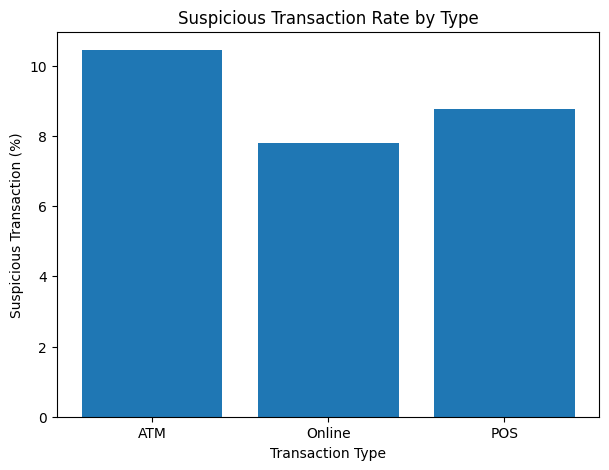

In [ ]:
type_probability = (
    df.groupby("Transaction_Type")["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean() * 100)
)

print(type_probability.round(2))

plt.figure(figsize=(7, 5))
plt.bar(
    type_probability.index,
    type_probability.values
)

plt.xlabel("Transaction Type")
plt.ylabel("Suspicious Transaction (%)")
plt.title("Suspicious Transaction Rate by Type")
plt.show()

# Location-Based Conditional Probability

### Explanation:
This code calculates the percwentage of suspicious transactions within each location
category.

In [ ]:
location_probability = (
    df.groupby("Location_Type")["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean() * 100)
)

print(location_probability.round(2))

Location_Type
Domestic          9.20
International    10.50
Local             7.25
Name: Transaction_Status, dtype: float64


# Location-Based Probability Graph

## Explanation:
This graph compares the suspicious transaction probability for Local, Domestic
and International transactions.

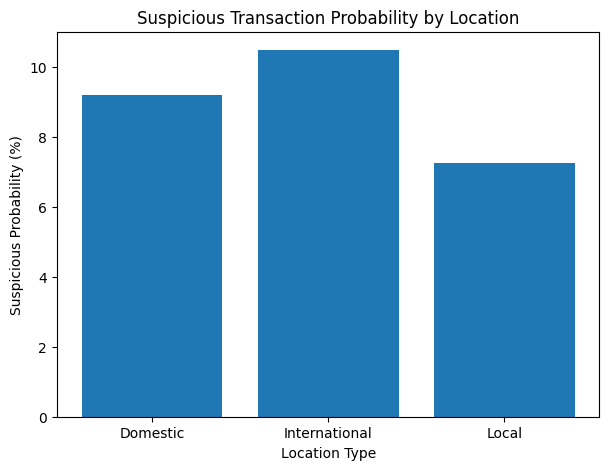

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    location_probability.index,
    location_probability.values
)

plt.xlabel("Location Type")
plt.ylabel("Suspicious Probability (%)")
plt.title("Suspicious Transaction Probability by Location")

plt.show()

## Transaction Amount Probability Distributin

# Explanation:
This code groups tranaction amount into fixed ranges and calculates the percentage probility of a transaction falling into each range.

In [ ]:
bins = [0, 500, 1000, 2000, 5000, np.inf]
labels = ["0-500", "500-1000", "1000-2000", "2000-5000", "5000+"]

df["Amount_Band"] = pd.cut(
    df["Transaction_Amount"],
    bins=bins,
    labels=labels,
    right=False
)

amount_probability = (
    df["Amount_Band"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print(amount_probability.round(2))

Amount_Band
0-500        20.6
500-1000     24.3
1000-2000    27.7
2000-5000    20.2
5000+         7.2
Name: proportion, dtype: float64


## Transaction Amount Probability Graph

## Explanation:
This graph shows the probability percentage of transactions occurring within each amount range.


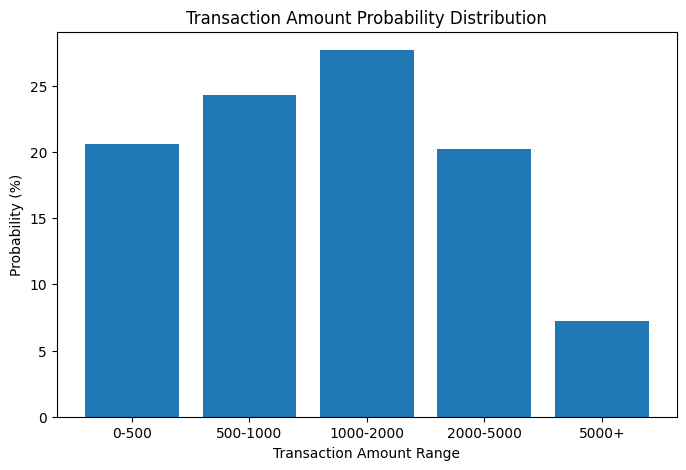

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    amount_probability.index.astype(str),
    amount_probability.values
)

plt.xlabel("Transaction Amount Range")
plt.ylabel("Probability (%)")
plt.title("Transaction Amount Probability Distribution")

plt.show()

## Outlier Analysis using IQR



# Explanation

This code uses the IQR method to find transaction amounts that fall unusually far below or above the central range of the data.

In [ ]:
q1 = df["Transaction_Amount"].quantile(0.25)
q3 = df["Transaction_Amount"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = df[
    (df["Transaction_Amount"] < lower_limit) |
    (df["Transaction_Amount"] > upper_limit)
]

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower limit:", round(lower_limit, 2))
print("Upper limit:", round(upper_limit, 2))
print("Number of outliers:", len(outliers))

Q1: 573.88
Q3: 2096.34
IQR: 1522.46
Lower limit: -1709.82
Upper limit: 4380.02
Number of outliers: 91


## Transaction Time Pattern Analysis

# Explanation

This analysis counts transactions for each hour of the day and visualizes the transaction activity pattern.



In [ ]:
print(df.head())

   Transaction_ID  Transaction_Amount  Transaction_Hour  Transaction_Day  \
0               1             1802.11                22               18   
1               2              955.02                11               20   
2               3             2095.80                16               17   
3               4             5029.27                 7               27   
4               5              867.70                10               28   

  Transaction_Type  Location_Type Transaction_Status Amount_Range Amount_Band  
0              ATM       Domestic             Normal         High   1000-2000  
1              ATM  International             Normal       Medium    500-1000  
2           Online          Local             Normal         High   2000-5000  
3           Online  International             Normal         High       5000+  
4           Online          Local             Normal       Medium    500-1000  


Transaction_Hour
0     36
1     46
2     42
3     50
4     43
5     38
6     36
7     47
8     40
9     42
10    34
11    46
12    42
13    42
14    43
15    33
16    38
17    45
18    38
19    41
20    50
21    44
22    50
23    34
Name: count, dtype: int64


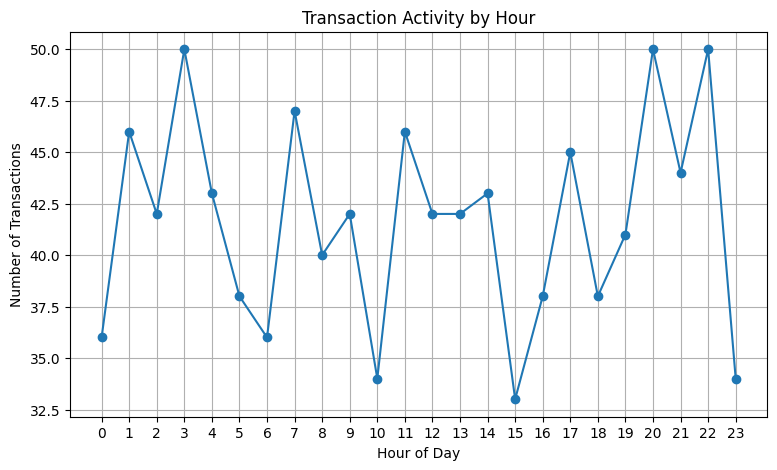

In [ ]:
hour_counts = (
    df["Transaction_Hour"]
    .value_counts()
    .sort_index()
)

print(hour_counts)

plt.figure(figsize=(9, 5))

plt.plot(
    hour_counts.index,
    hour_counts.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.title("Transaction Activity by Hour")

plt.xticks(range(0, 24))
plt.grid(True)

plt.show()

## Time-Based Suspicious Probability

# Explanation:
This analysis calculates the percentage of
suspicious transactionfor each hour and
visualizes how that probability changes
throughout the day.

Transaction_Hour
0      5.56
1     17.39
2      9.52
3     10.00
4     11.63
5     15.79
6      5.56
7     10.64
8      7.50
9     16.67
10    11.76
11     2.17
12    11.90
13     9.52
14    11.63
15     3.03
16     2.63
17     6.67
18     7.89
19     0.00
20     6.00
21    13.64
22     6.00
23    11.76
Name: Transaction_Status, dtype: float64


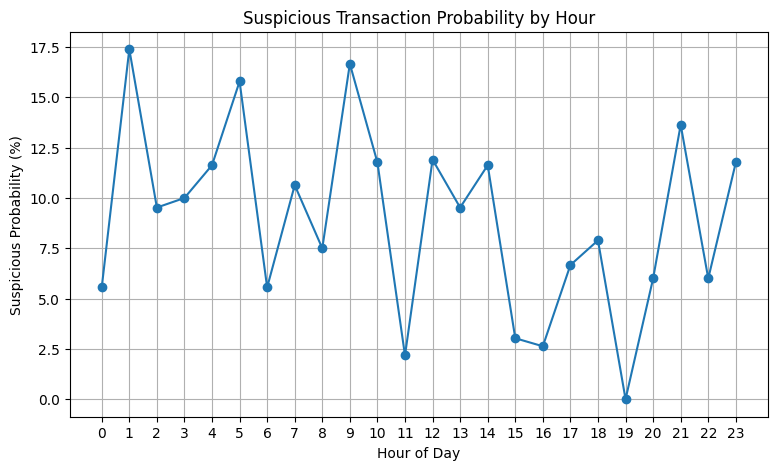

In [ ]:
hour_probability = (
    df.groupby("Transaction_Hour")["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean() * 100)
)

print(hour_probability.round(2))

plt.figure(figsize=(9, 5))

plt.plot(
    hour_probability.index,
    hour_probability.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Suspicious Probability (%)")
plt.title("Suspicious Transaction Probability by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

## Day-Wise Transaction Pattern Analysis

# Explanation:
This code counts transaction for each day of the
month and displays the daily transaction pattern
using a line graph.

Transaction_Day
1     31
2     32
3     40
4     34
5     33
6     36
7     26
8     32
9     37
10    24
11    32
12    34
13    34
14    33
15    34
16    25
17    38
18    26
19    37
20    34
21    42
22    33
23    29
24    37
25    33
26    31
27    34
28    47
29    30
30    32
Name: count, dtype: int64


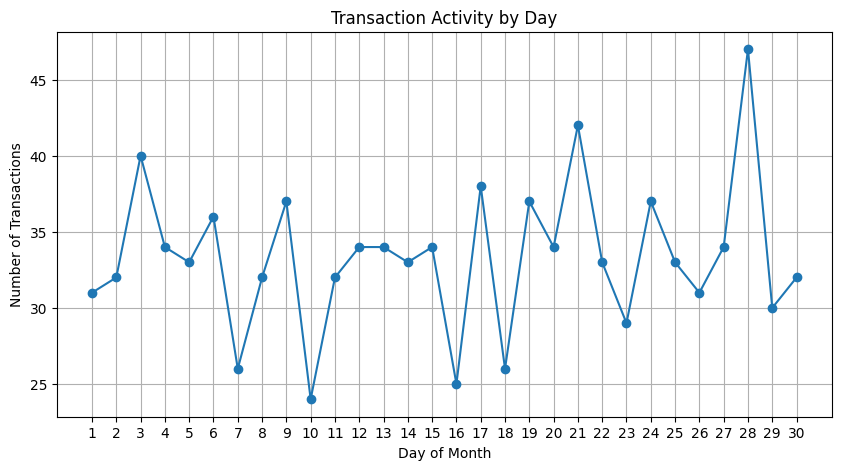

In [ ]:
day_counts = (
    df["Transaction_Day"]
    .value_counts()
    .sort_index()
)

print(day_counts)

plt.figure(figsize=(10, 5))

plt.plot(
    day_counts.index,
    day_counts.values,
    marker="o"
)

plt.xlabel("Day of Month")
plt.ylabel("Number of Transactions")
plt.title("Transaction Activity by Day")

plt.xticks(range(1, 31))
plt.grid(True)

plt.show()

## Day-Wise Suspicious Probability

# Explanation:
This analysis calculates the suspicious
transaction percentage for each day and visualizes
how it changes throughout the month.

Transaction_Day
1      9.68
2      9.38
3      7.50
4     14.71
5      0.00
6     11.11
7      3.85
8      6.25
9      5.41
10     0.00
11     3.12
12    17.65
13    11.76
14     9.09
15    14.71
16     8.00
17     5.26
18     3.85
19    16.22
20    20.59
21    11.90
22     6.06
23    10.34
24     8.11
25     9.09
26     3.23
27     2.94
28    12.77
29    13.33
30     6.25
Name: Transaction_Status, dtype: float64


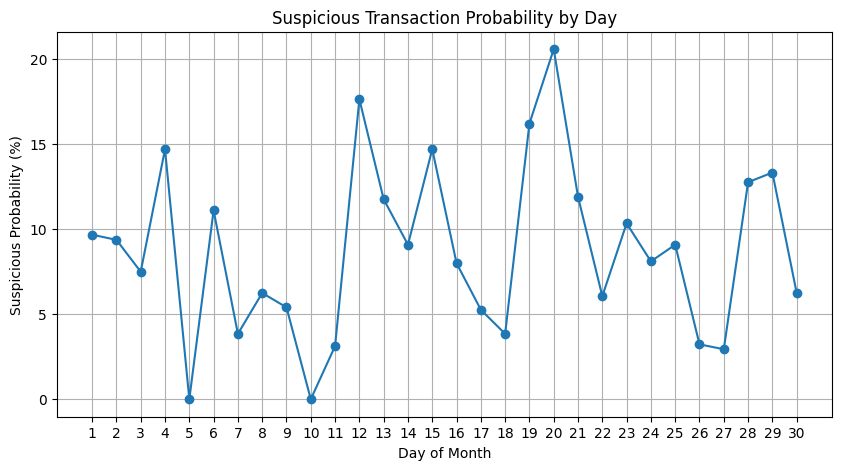

In [ ]:
day_probability = (
    df.groupby("Transaction_Day")["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean() * 100)
)

print(day_probability.round(2))

plt.figure(figsize=(10, 5))

plt.plot(
    day_probability.index,
    day_probability.values,
    marker="o"
)

plt.xlabel("Day of Month")
plt.ylabel("Suspicious Probability (%)")
plt.title("Suspicious Transaction Probability by Day")

plt.xticks(range(1, 31))
plt.grid(True)

plt.show()

## Cmbined Transaction Type and Location Analysis

# Explanation:
This code calculates the suspicious transaction
percentage for every combination of transaction
type and location.

In [ ]:
combined_probability = (
    df.groupby(
        ["Transaction_Type", "Location_Type"]
    )["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean() * 100)
    .round(2)
)

print(combined_probability)

Transaction_Type  Location_Type
ATM               Domestic          7.41
                  International    13.95
                  Local             9.18
Online            Domestic          9.65
                  International     9.17
                  Local             4.46
POS               Domestic         10.58
                  International     7.45
                  Local             8.26
Name: Transaction_Status, dtype: float64


## Combined Probability Heatmap

# Explanation:
 This heatmap displays the suspicious transaction
probability for each combination type and location.

Location_Type     Domestic  International  Local
Transaction_Type                                
ATM                   7.41          13.95   9.18
Online                9.65           9.17   4.46
POS                  10.58           7.45   8.26


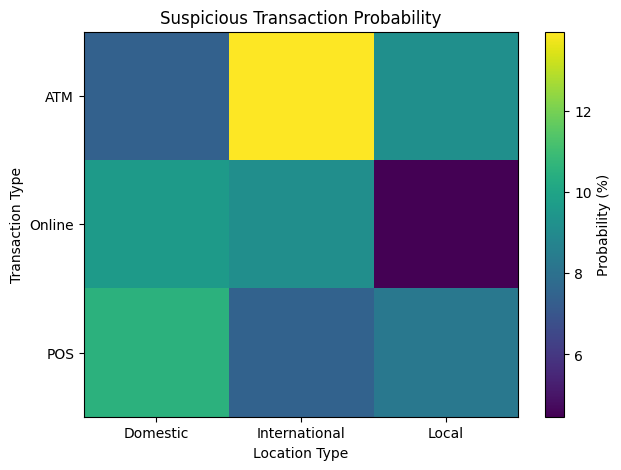

In [ ]:
heatmap_data = (
    df.assign(
        Suspicious=df["Transaction_Status"] == "Suspicious"
    )
    .pivot_table(
        values="Suspicious",
        index="Transaction_Type",
        columns="Location_Type",
        aggfunc="mean"
    )
    .mul(100)
)

print(heatmap_data.round(2))

plt.figure(figsize=(7, 5))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Location Type")
plt.ylabel("Transaction Type")
plt.title("Suspicious Transaction Probability")

plt.colorbar(label="Probability (%)")

plt.show()

## Correlation Analysis

# Explanation:
This code calculates the correlation between
numerical transaction variables and display
the relationships using heatmap.

                    Transaction_Amount  Transaction_Hour  Transaction_Day
Transaction_Amount                1.00             -0.01            -0.05
Transaction_Hour                 -0.01              1.00            -0.02
Transaction_Day                  -0.05             -0.02             1.00


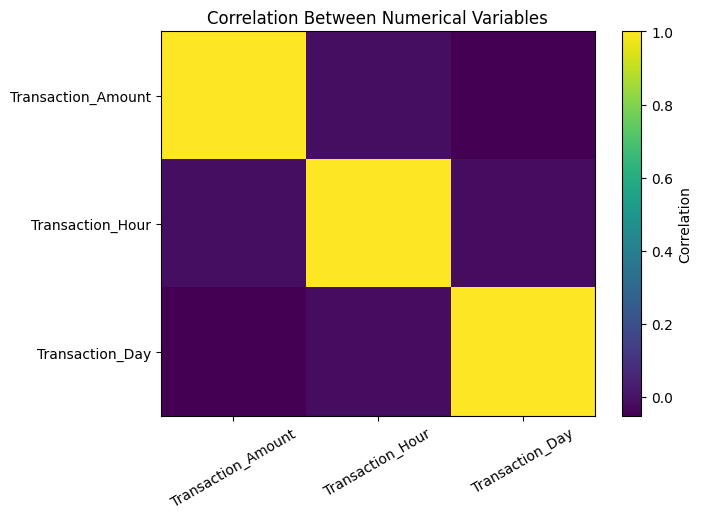

In [ ]:
numeric_data = df[
    [
        "Transaction_Amount",
        "Transaction_Hour",
        "Transaction_Day"
    ]
]

correlation = numeric_data.corr()

print(correlation.round(2))

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=30
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.colorbar(label="Correlation")
plt.title("Correlation Between Numerical Variables")

plt.show()

## Statistical Risk Score

# Explanation:
This code creates a statistical risk score from transaction amount, transaction time,
location and transaction type. Each factor is given a predenfined weight and the final
score is scaled between 0 and 100.

In [ ]:
df["Amount_Score"] = (
    df["Transaction_Amount"]
    .rank(pct=True)
    * 100
)

df["Hour_Score"] = (
    df["Transaction_Hour"]
    .apply(
        lambda x: 100 if x < 6 or x > 22 else 20
    )
)

df["Location_Score"] = (
    df["Location_Type"]
    .map({
        "Local": 20,
        "Domestic": 50,
        "International": 80
    })
)

df["Type_Score"] = (
    df["Transaction_Type"]
    .map({
        "POS": 20,
        "ATM": 40,
        "Online": 60
    })
)

df["Risk_Score"] = (
    0.40 * df["Amount_Score"] +
    0.20 * df["Hour_Score"] +
    0.25 * df["Location_Score"] +
    0.15 * df["Type_Score"]
)

df["Risk_Score"] = df["Risk_Score"].clip(0, 100)

print(
    df[
        [
            "Transaction_ID",
            "Transaction_Amount",
            "Transaction_Type",
            "Location_Type",
            "Risk_Score"
        ]
    ].head(10).round(2)
)

   Transaction_ID  Transaction_Amount Transaction_Type  Location_Type  \
0               1             1802.11              ATM       Domestic   
1               2              955.02              ATM  International   
2               3             2095.80           Online          Local   
3               4             5029.27           Online  International   
4               5              867.70           Online          Local   
5               6              867.71              POS          Local   
6               7             5319.92              POS       Domestic   
7               8             2362.40              POS          Local   
8               9              685.76           Online          Local   
9              10             1886.65              ATM       Domestic   

   Risk_Score  
0       50.22  
1       47.44  
2       48.00  
3       70.16  
4       34.20  
5       44.24  
6       73.14  
7       43.60  
8       47.04  
9       50.86  


## Risk CategoryAnalysis

# Explanation:
This code converts the numerical risk score into four categories and displays their distribution in a bar graph.

Risk_Category
Low         126
Medium      669
High        180
Critical     25
Name: count, dtype: int64


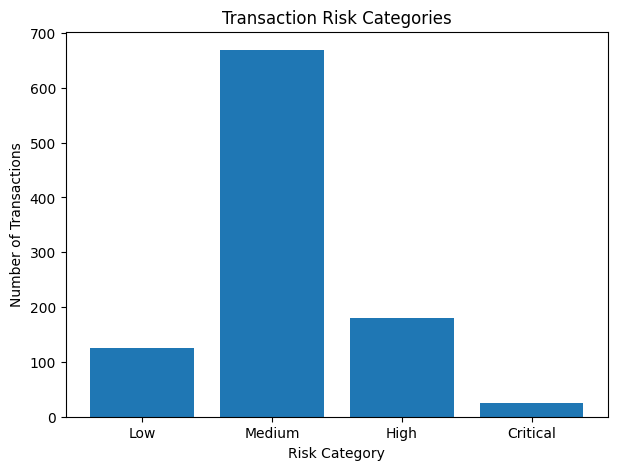

In [ ]:
df["Risk_Category"] = pd.cut(
    df["Risk_Score"],
    bins=[-1, 30, 60, 80, 100],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

risk_counts = df["Risk_Category"].value_counts().reindex(
    ["Low", "Medium", "High", "Critical"],
    fill_value=0
)

print(risk_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Transactions")
plt.title("Transaction Risk Categories")

plt.show()

## High_Risk Transaction Analysis

# Explanation:
This analysis filters High and Critical risk
transactions and summarizes their amount,
transaction type, and location patterns.

In [ ]:
high_risk = df[
    df["Risk_Category"].isin(["High", "Critical"])
].copy()

print("High-risk transactions:", len(high_risk))

print("\nRisk category:")
print(high_risk["Risk_Category"].value_counts())

print("\nAverage transaction amount:")
print(round(high_risk["Transaction_Amount"].mean(), 2))

print("\nTransaction type:")
print(high_risk["Transaction_Type"].value_counts())

print("\nLocation type:")
print(high_risk["Location_Type"].value_counts())

High-risk transactions: 205

Risk category:
Risk_Category
High        180
Critical     25
Medium        0
Low           0
Name: count, dtype: int64

Average transaction amount:
4026.02

Transaction type:
Transaction_Type
ATM       79
Online    76
POS       50
Name: count, dtype: int64

Location type:
Location_Type
International    120
Domestic          63
Local             22
Name: count, dtype: int64


## High-Risk Transaction Comparison

# Explanation:
This boxplot compares the transaction amount
distribution of lower-risk and higher-risk groups.

/tmp/ipykernel_947/1848196394.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


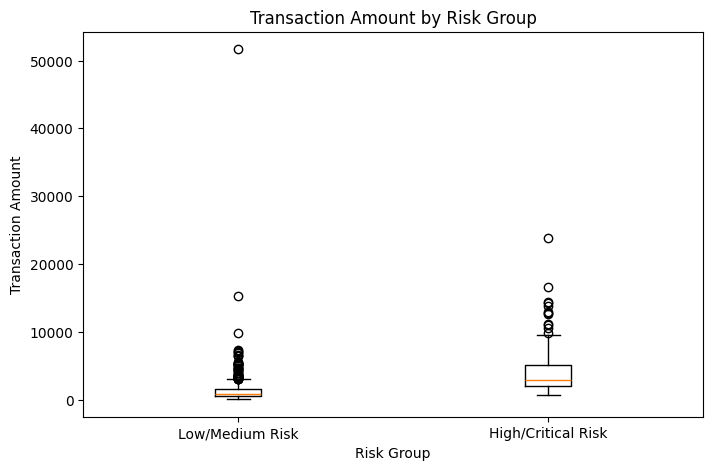

In [ ]:
normal = df[
    df["Risk_Category"].isin(["Low", "Medium"])
]

high = df[
    df["Risk_Category"].isin(["High", "Critical"])
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        normal["Transaction_Amount"],
        high["Transaction_Amount"]
    ],
    labels=["Low/Medium Risk", "High/Critical Risk"]
)

plt.xlabel("Risk Group")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount by Risk Group")

plt.show()

## Risk Category Probability Analysis

# Explanation:
This code calculates the percentage probability
of a transaction belonging to each risk category.

In [ ]:
risk_probability = (
    df["Risk_Category"]
    .value_counts(normalize=True)
    .reindex(
        ["Low", "Medium", "High", "Critical"],
        fill_value=0
    )
    .mul(100)
)

print(risk_probability.round(2))

Risk_Category
Low         12.6
Medium      66.9
High        18.0
Critical     2.5
Name: proportion, dtype: float64


## Risk Probability Graph

# This graph compares the probability of transations
falling into Low, Medium, High, and Critical risk
categories.

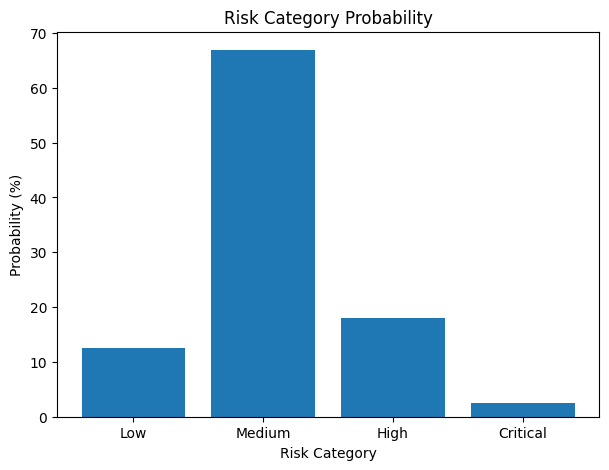

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    risk_probability.index,
    risk_probability.values
)

plt.xlabel("Risk Category")
plt.ylabel("Probability (%)")
plt.title("Risk Category Probability")

plt.show()

## Hypothesis Testing

# Explanation:
This test compares the average transaction amount
of two risk groups.

*Null hypothesis: The two groups have the same
 average transaction amount.

 * Alternative hypothesis: The two groups have
 different averge transaction amount.

 * We use 0.05 as the significance level.

In [ ]:
from scipy.stats import ttest_ind

low_medium = df[
    df["Risk_Category"].isin(["Low", "Medium"])
]["Transaction_Amount"]

high_critical = df[
    df["Risk_Category"].isin(["High", "Critical"])
]["Transaction_Amount"]

t_stat, p_value = ttest_ind(
    low_medium,
    high_critical,
    equal_var=False
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Significant difference")
else:
    print("Result: No significant difference")

T-statistic: -11.3104
P-value: 0.0
Result: Significant difference


## Confidence Interval Analysis

# Explanation:
This code calculates a 95% confidence interval for the mean
tranasaction amount of the High/Critical risk
group.

In [ ]:
from scipy.stats import t

high_amount = df[
    df["Risk_Category"].isin(["High", "Critical"])
]["Transaction_Amount"]

mean_value = high_amount.mean()
std_value = high_amount.std()
n = len(high_amount)

se = std_value / np.sqrt(n)
margin = t.ppf(0.975, n - 1) * se

lower = mean_value - margin
upper = mean_value + margin

print("Mean:", round(mean_value, 2))
print("95% Confidence Interval:")
print("Lower:", round(lower, 2))
print("Upper:", round(upper, 2))

Mean: 4026.02
95% Confidence Interval:
Lower: 3572.54
Upper: 4479.5


## Risk Score vs Transaction Amount

# Explanation:
This Scatter plot compares transaction amount
with their calculated risk scores. it helps
visualize whether higher transaction amounts
tend to be associated with higher risk scores.

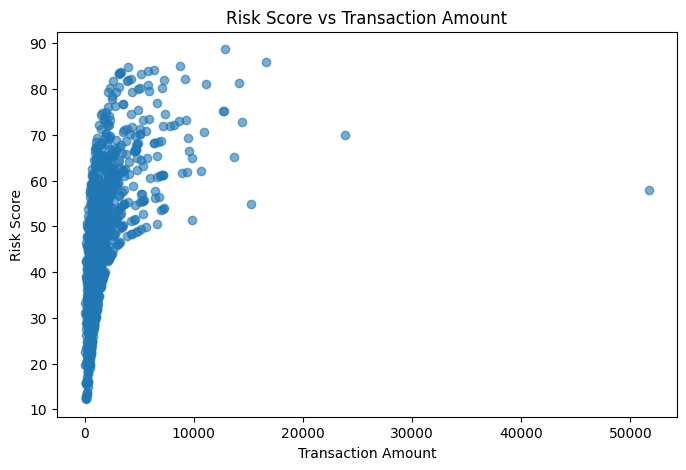

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Transaction_Amount"],
    df["Risk_Score"],
    alpha=0.6
)

plt.xlabel("Transaction Amount")
plt.ylabel("Risk Score")
plt.title("Risk Score vs Transaction Amount")

plt.show()

## What-if Risk Probability Analysis

# Explanation:
This analysis compares suspicious transaction
probabilities across different location types
and allow us to examine how the probability changes
when the location condition changes.

In [ ]:
location_rates = (
    df.groupby("Location_Type")["Transaction_Status"]
    .apply(lambda x: (x == "Suspicious").mean() * 100)
)

print(location_rates.round(2))

locations = ["Local", "Domestic", "International"]

for location in locations:
    print(
        location,
        "->",
        round(location_rates.get(location, 0), 2),
        "%"
    )

Location_Type
Domestic          9.20
International    10.50
Local             7.25
Name: Transaction_Status, dtype: float64
Local -> 7.25 %
Domestic -> 9.2 %
International -> 10.5 %


## Final Statistical Summary

# Explanation:
This code collects the main statistical and risk-related
results from the project into one summary table.

In [ ]:
summary = {
    "Total Transactions": len(df),
    "Average Amount": round(df["Transaction_Amount"].mean(), 2),
    "Median Amount": round(df["Transaction_Amount"].median(), 2),
    "Standard Deviation": round(df["Transaction_Amount"].std(), 2),
    "Outliers": len(outliers),
    "High/Critical Transactions": len(high_risk),
    "Most Common Risk": df["Risk_Category"].mode()[0],
    "Highest Risk Score": round(df["Risk_Score"].max(), 2)
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Measure", "Value"]
)

display(summary_df)

,Measure,Value
0,Total Transactions,1000
1,Average Amount,1844.9
2,Median Amount,1124.73
3,Standard Deviation,2682.53
4,Outliers,91
5,High/Critical Transactions,205
6,Most Common Risk,Medium
7,Highest Risk Score,88.72


## Final Risk Analysis Graph

# Explanation:
This graph provides a final visual comparison
of the number of tranasaction in each risk
category.

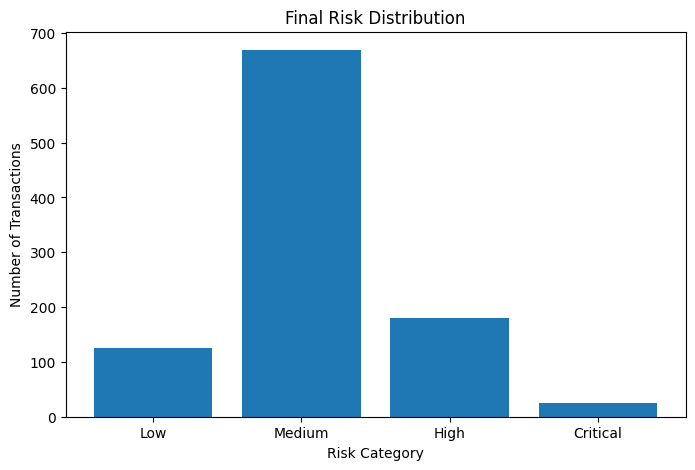

In [ ]:
risk_counts = (
    df["Risk_Category"]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High", "Critical"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Transactions")
plt.title("Final Risk Distribution")

plt.show()

## Final Conclusion

# Explanation:
This code presents the final results of the
transaction analysis and risk categorization.

In [ ]:
total = len(df)
high_risk_count = len(
    df[df["Risk_Category"].isin(["High", "Critical"])]
)

high_risk_percent = (high_risk_count / total) * 100

print("Total transactions:", total)
print("High/Critical transactions:", high_risk_count)
print("High/Critical percentage:", round(high_risk_percent, 2))
print("Average transaction amount:", round(df["Transaction_Amount"].mean(), 2))
print("Most common risk category:", df["Risk_Category"].mode()[0])

Total transactions: 1000
High/Critical transactions: 205
High/Critical percentage: 20.5
Average transaction amount: 1844.9
Most common risk category: Medium
